In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("heart.csv")
print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")

Данные загружены: 1025 строк, 14 столбцов


In [2]:
X = df.drop("target", axis=1)
y = df["target"]
print(f"Признаки: {X.shape}, Целевая переменная: {y.shape}")

Признаки: (1025, 13), Целевая переменная: (1025,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Обучающая выборка: 820 строк
Тестовая выборка: 205 строк


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Данные нормализованы")

Данные нормализованы


In [5]:
print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy: {acc_lr:.3f}")
print(f"F1-score: {f1_lr:.3f}")
print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nОтчёт классификации:")
print(classification_report(y_test, y_pred_lr, target_names=["Здоров", "Болен"]))

LOGISTIC REGRESSION
Accuracy: 0.810
F1-score: 0.831

Матрица ошибок:
[[70 30]
 [ 9 96]]

Отчёт классификации:
              precision    recall  f1-score   support

      Здоров       0.89      0.70      0.78       100
       Болен       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



In [6]:
print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {acc_rf:.3f}")
print(f"F1-score: {f1_rf:.3f}")
print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nОтчёт классификации:")
print(classification_report(y_test, y_pred_rf, target_names=["Здоров", "Болен"]))

RANDOM FOREST
Accuracy: 1.000
F1-score: 1.000

Матрица ошибок:
[[100   0]
 [  0 105]]

Отчёт классификации:
              precision    recall  f1-score   support

      Здоров       1.00      1.00      1.00       100
       Болен       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [7]:
print("=" * 50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 50)

results = pd.DataFrame({
    "Модель": ["Logistic Regression", "Random Forest"],
    "Accuracy": [acc_lr, acc_rf],
    "F1-score": [f1_lr, f1_rf]
})
print(results.to_string(index=False))

СРАВНЕНИЕ МОДЕЛЕЙ
             Модель  Accuracy  F1-score
Logistic Regression  0.809756  0.831169
      Random Forest  1.000000  1.000000


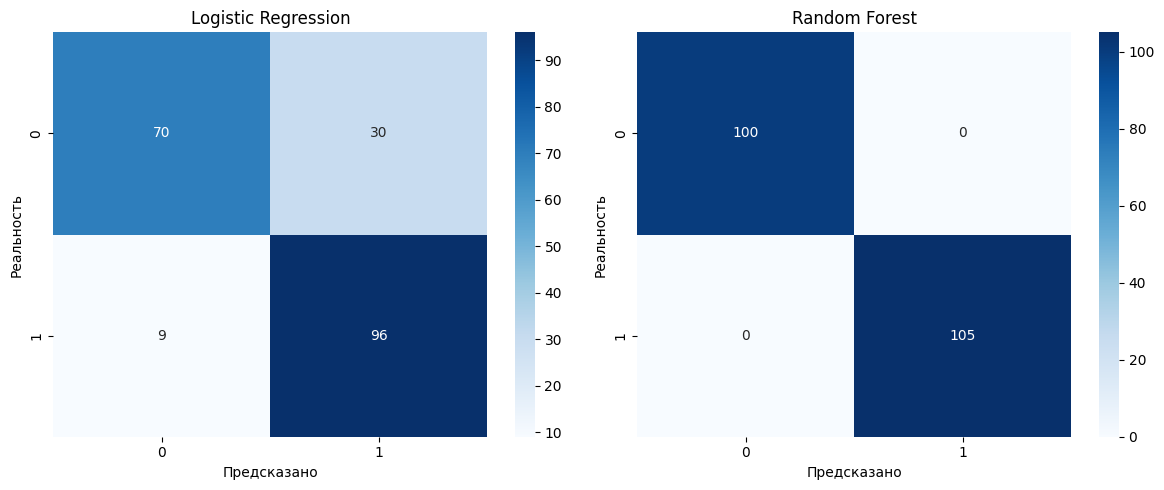

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Предсказано")
axes[0].set_ylabel("Реальность")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Предсказано")
axes[1].set_ylabel("Реальность")

plt.tight_layout()
plt.show()

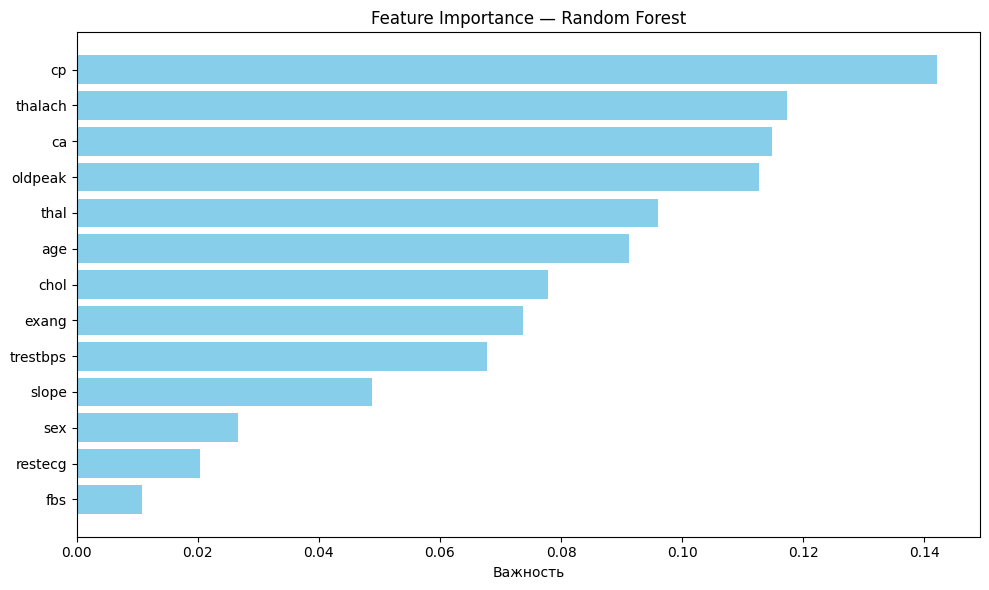

Топ-5 важных признаков:
Признак  Важность
     cp  0.142094
thalach  0.117349
     ca  0.114844
oldpeak  0.112634
   thal  0.095930


In [9]:
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color="skyblue")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Важность")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

fi_df = pd.DataFrame({"Признак": features, "Важность": importances})
fi_df = fi_df.sort_values("Важность", ascending=False)
print("Топ-5 важных признаков:")
print(fi_df.head(5).to_string(index=False))